# Gender Income Inequality in the United States
## Examining What ACS Data Reveals—and What It Doesn't—About Systemic Disparities

## Overview
This analysis examines income disparities by gender using the 2018 American Community Survey (ACS) data. While the dataset exemplifies responsible data collection practices, including gender as a variable with balanced representation, it reveals persistent and systematic income inequality across education levels, occupations, and age groups.

## Research Question
Is collecting gender data sufficient for understanding and addressing income inequality?

## Dataset
- **Source**: American Community Survey (ACS) 2018 via fairlearn library
- **Coverage**: All 50 US states
- **Sample size**: 1664500 observations
- **Key variables**: Age, Sex, Race, Education, Occupation, Income

## Motivation
Inspired by Caroline Criado Perez's *Invisible Women*, which argues for the necessity of gender-disaggregated data, this project explores whether simply collecting gender data is sufficient for understanding and addressing inequality. The findings suggest that visibility (having the data) is necessary but not sufficient for actionability (using the data to drive change).

---

## 1. Setup and Data Loading


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.datasets import fetch_acs_income

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
data = fetch_acs_income()
income_df = data.data
income_df['PINCP'] = data.target


print(f"Dataset loaded: {income_df.shape[0]:,} observations, {income_df.shape[1]} variables")


Dataset loaded: 1,664,500 observations, 11 variables


## 2. Data Preparation

Before analysis, we decode categorical variables for interpretability.

In [12]:
# Decoding Sex Variable 
income_df['sex'] = income_df['SEX'].map({1.0: 'Male', 2.0: 'Female'})

print("Gender Count: ")
print(income_df['sex'].value_counts())

print("\nGender Distribution: ")
print(income_df['sex'].value_counts(normalize=True).round(3))


Gender Count: 
sex
Male      866735
Female    797765
Name: count, dtype: int64

Gender Distribution: 
sex
Male      0.521
Female    0.479
Name: proportion, dtype: float64


## 3. Overall Gender Income Gap

We begin by examining the baseline income disparity between men and women across the entire dataset.

In [24]:
income_by_sex = income_df.groupby('sex')['PINCP'].median().sort_values(ascending=False)
gap_absolute = income_by_sex['Male'] - income_by_sex['Female']
gap_percent = (gap_absolute / income_by_sex['Male']) * 100

print(f"\n📊 Income Gap:")
print(f"Absolute: ${gap_absolute:,.0f}")
print(f"Percentage: {gap_percent:.1f}%")
print(f"\nWomen earn {100-gap_percent:.1f}% of what men earn.")



📊 Income Gap:
Absolute: $13,000
Percentage: 28.9%

Women earn 71.1% of what men earn.


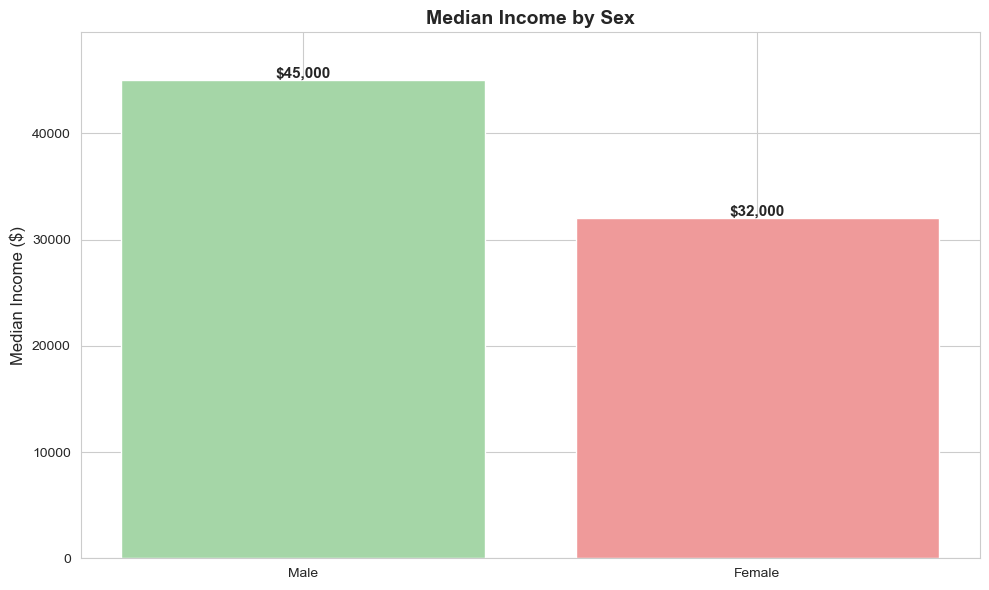

In [40]:
bars = plt.bar(income_by_sex.index, income_by_sex.values, color=['#A5D6A7', '#EF9A9A'])
plt.ylabel('Median Income ($)', fontsize=12)
plt.title('Median Income by Sex', fontsize=14, fontweight='bold')
plt.ylim(0, income_by_sex.max() * 1.1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Key Finding📉
Women earn a median income of $32,000, while men earn $45,000—a gap of $13,000 (28.9%). This disparity persists even with balanced gender representation in the dataset (~50/50).

## The Gap Persists Across Contexts

The overall gap could be explained by demographic differences. However, examining income within specific contexts reveals the gap is systematic, not coincidental.

### By Education Level

In [49]:
def education_group(schl):
    if schl <= 15:
        return 'Less than HS'
    elif schl <= 17:
        return 'High School'
    elif schl <= 19:
        return 'Some College'
    elif schl == 20:
        return "Associate's"
    elif schl == 21:
        return "Bachelor's"
    elif schl == 22:
        return "Master's"
    elif schl >= 23:
        return 'Professional/Doctorate'
    else:
        return 'Unknown'

income_df['education'] = income_df['SCHL'].apply(education_group)




<Figure size 1200x600 with 0 Axes>

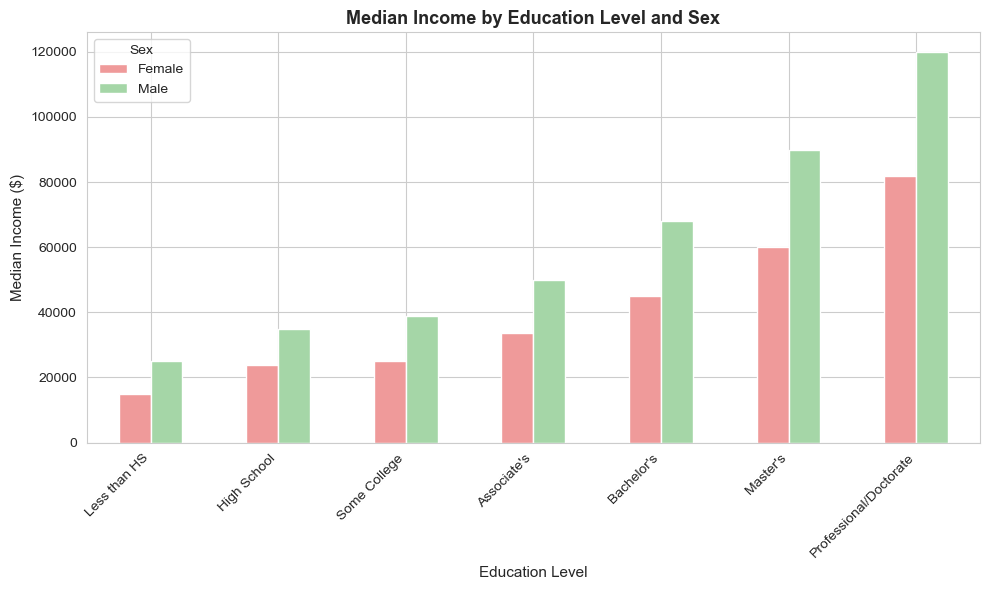

In [63]:
income_by_edu_sex = income_df.groupby(['education', 'sex'])['PINCP'].median().reset_index()
pivot_edu = income_by_edu_sex.pivot(index='education', columns='sex', values='PINCP')

# ordered for clarity
edu_order = ['Less than HS', 'High School', 'Some College', "Associate's", 
             "Bachelor's", "Master's", 'Professional/Doctorate']
pivot_edu = pivot_edu.reindex(edu_order)

plt.figure(figsize=(12, 6))
pivot_edu.plot(kind='bar', color=['#EF9A9A','#A5D6A7'])
plt.xlabel('Education Level', fontsize=11)
plt.ylabel('Median Income ($)', fontsize=11)
plt.title('Median Income by Education Level and Sex', fontsize=13, fontweight='bold')
plt.legend(title='Sex')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### By Sex and Race Level

In [80]:
race_mapping = {
    1: 'White',
    2: 'African American',
    3: 'American Indian',
    4: 'Alaska Native',
    5: 'American Indian/Alaska Native',
    6: 'Asian',
    7: 'Native Hawaiian/Pacific Islander',
    8: 'Other Race',
    9: 'Two or More Races'
}

income_df['race'] = income_df['RAC1P'].map(race_mapping)

In [81]:
income_df

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,PINCP,sex,education,race
0,18.0,1.0,18.0,5.0,4720.0,13.0,17.0,21.0,2.0,2.0,1600.0,Female,Some College,African American
1,53.0,5.0,17.0,5.0,3605.0,18.0,16.0,40.0,1.0,1.0,10000.0,Male,High School,White
2,41.0,1.0,16.0,5.0,7330.0,1.0,17.0,40.0,1.0,1.0,24000.0,Male,High School,White
3,18.0,6.0,18.0,5.0,2722.0,1.0,17.0,2.0,2.0,1.0,180.0,Female,Some College,White
4,21.0,5.0,19.0,5.0,3870.0,12.0,17.0,50.0,1.0,1.0,29000.0,Male,Some College,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1664495,39.0,6.0,16.0,5.0,6260.0,72.0,0.0,20.0,1.0,1.0,9600.0,Male,High School,White
1664496,38.0,6.0,14.0,5.0,4251.0,72.0,0.0,32.0,1.0,8.0,2400.0,Male,Less than HS,Other Race
1664497,37.0,1.0,19.0,3.0,7750.0,17.0,13.0,40.0,2.0,9.0,19700.0,Female,Some College,Two or More Races
1664498,47.0,1.0,16.0,1.0,8990.0,72.0,1.0,40.0,1.0,8.0,18700.0,Male,High School,Other Race


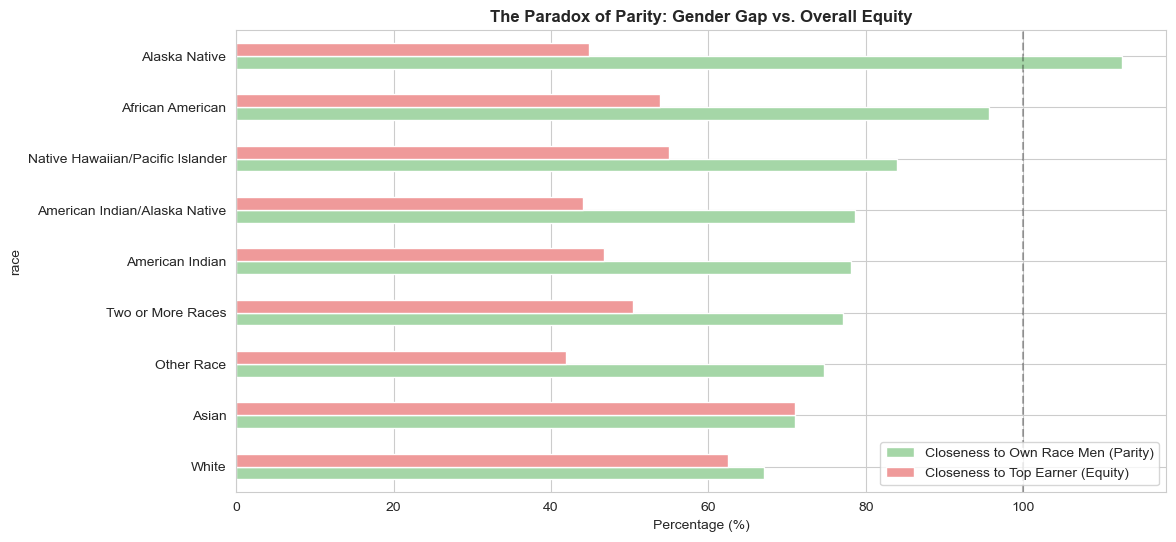

In [83]:

grouped = income_df.groupby(['race', 'sex'])['PINCP'].median().unstack()

# 1. Gender Parity Ratio (How close women are to men in their own race)
grouped['Gender_Parity'] = (grouped['Female'] / grouped['Male']) * 100

# 2. Total Baseline Ratio (How close women are to the top earner in the dataset)
baseline = grouped['Male'].max()
grouped['Baseline_Equity'] = (grouped['Female'] / baseline) * 100

# 3. Plotting them side-by-side
fig, ax = plt.subplots(figsize=(12, 6))

# We plot the 'Closeness to their own men' vs 'Closeness to the top'
grouped[['Gender_Parity', 'Baseline_Equity']].sort_values('Gender_Parity').plot(
    kind='barh', ax=ax, color=['#A5D6A7','#EF9A9A']
)

plt.title('The Paradox of Parity: Gender Gap vs. Overall Equity', fontweight='bold')
plt.xlabel('Percentage (%)')
plt.legend(['Closeness to Own Race Men (Parity)', 'Closeness to Top Earner (Equity)'])
plt.axvline(x=100, color='black', linestyle='--', alpha=0.3)
plt.show()

Median hours worked per week:
sex
Female    40.0
Male      40.0
Name: WKHP, dtype: float64


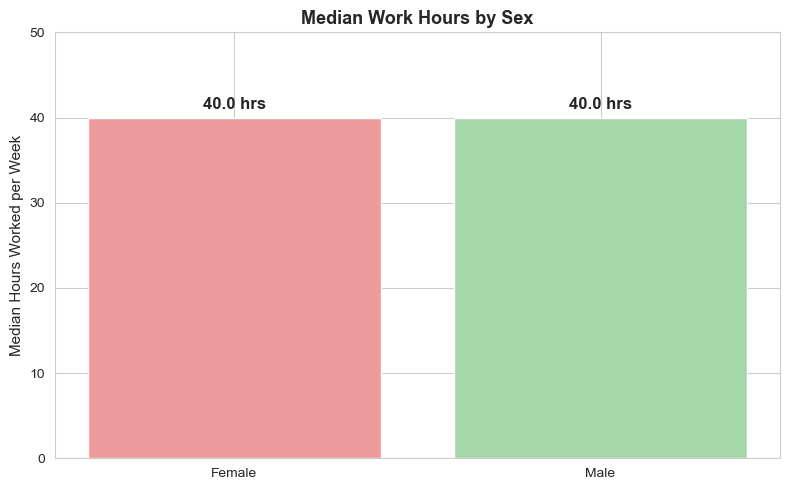

In [96]:
median_hours = income_df.groupby("sex")["WKHP"].median()
print("Median hours worked per week:")
print(median_hours)

# Visualize
plt.figure(figsize=(8, 5))
bars = plt.bar(median_hours.index, median_hours.values, color=['#EF9A9A', '#A5D6A7'])
plt.ylabel('Median Hours Worked per Week', fontsize=11)
plt.title('Median Work Hours by Sex', fontsize=13, fontweight='bold')
plt.ylim(0, 50)

# Add value labels
for i, (sex, hours) in enumerate(median_hours.items()):
    plt.text(i, hours + 1, f'{hours} hrs', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Finding 📉
Women consistently earn less than men at every level of education. This pattern holds not only across education levels, but also within the same age groups, occupations, and racial categories. The gap is systematic, not coincidental.

**This raises a critical question:** If the disparity persists across all demographic contexts, what's driving it? The data makes inequality visible, but does it make it understandable?

---
## 4. What This Data Can and Cannot Tell Us

### 4.1 The Problem

The ACS data successfully documents widespread income inequality. The pattern is clear: women earn less than men across education levels, age groups, and occupations.

But **documentation is not explanation.** We can see the gap exists, but we cannot see why. **This gap between visibility and understanding creates a policy problem: we know inequality exists, but we don't have the data needed to design targeted, effective interventions.**



### 4.2 What We CAN See 

*Women earn 28.9% less than men.*


This gap persists across education levels, across occupations, across age groups, and compounds intersectionally for women of color. 


**The data successfully makes inequality visible.**

### 4.3 The "Reference Person" Problem: When Data Exists But Still Obscures

The ACS dataset includes RELP (relationship to householder), which codes individuals by their relationship to a household "reference person":
- Reference person (head of household)
- Husband/wife (spouse)
- Children, relatives, roommates, etc.

**This structure itself encodes assumptions:**

1. **Households are the economic unit** (not individuals)
2. **Someone is the "reference"** (implying primary earner/decision-maker)
3. **Others are defined relationally** (wife of, child of)

Let's examine what this reveals:

Median Income by Household Role and Sex:
sex                Female     Male
relationship                      
Reference person  40000.0  58000.0
Spouse            36000.0  56000.0

Distribution by Sex (%):
sex               Female  Male
relationship                  
Reference person    46.7  53.3
Spouse              53.2  46.8


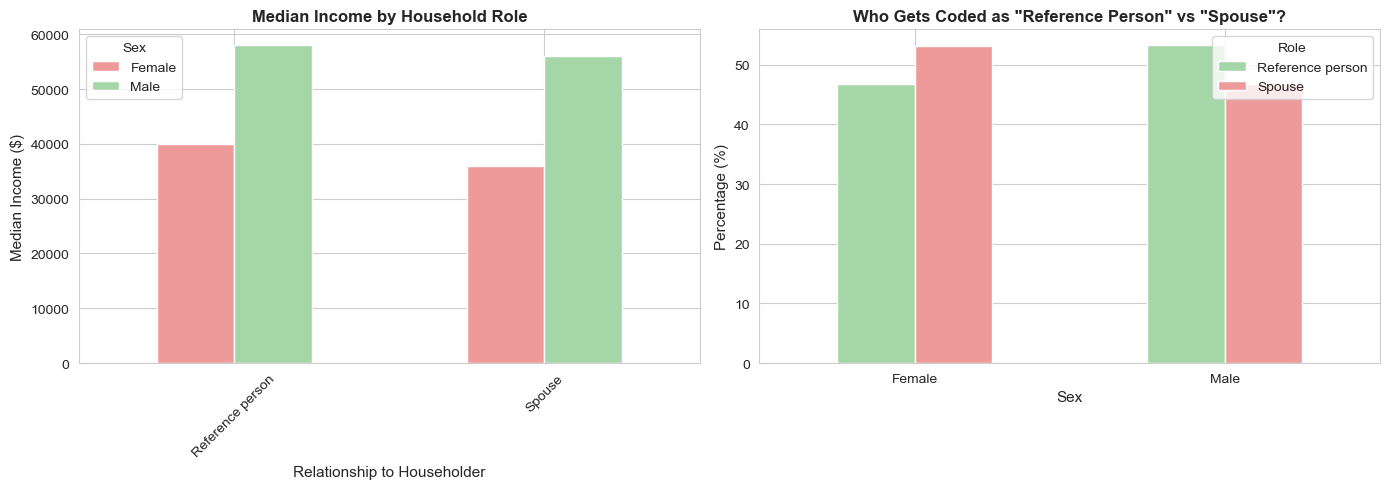

In [98]:
# Decode RELP for key categories
relp_mapping = {
    0: 'Reference person',
    1: 'Spouse',
    2: 'Biological child',
    3: 'Adopted child',
    4: 'Stepchild',
    5: 'Sibling',
    6: 'Parent',
    7: 'Grandchild',
    8: 'Parent-in-law',
    9: 'Child-in-law',
    10: 'Other relative',
    11: 'Roomer/boarder',
    12: 'Housemate/roommate',
    13: 'Unmarried partner',
    14: 'Foster child',
    15: 'Other nonrelative',
    16: 'Institutionalized',
    17: 'Noninstitutionalized group quarters'
}

income_df['relationship'] = income_df['RELP'].map(relp_mapping)

# Focus on Reference Person vs Spouse
key_relp_df = income_df[income_df['RELP'].isin([0,1])]
income_by_relp_sex = key_relp_df.groupby(['relationship', 'sex'])['PINCP'].median().unstack()

print("Median Income by Household Role and Sex:")
print(income_by_relp_sex)

# Check distribution - who gets coded as what?
relp_dist = key_relp_df.groupby(['relationship', 'sex']).size().unstack(fill_value=0)
relp_dist_pct = relp_dist.div(relp_dist.sum(axis=1), axis=0) * 100

print("\nDistribution by Sex (%):")
print(relp_dist_pct.round(1))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Income by role
income_by_relp_sex.plot(kind='bar', ax=ax1, color=['#EF9A9A', '#A5D6A7'])
ax1.set_ylabel('Median Income ($)', fontsize=11)
ax1.set_xlabel('Relationship to Householder', fontsize=11)
ax1.set_title('Median Income by Household Role', fontsize=12, fontweight='bold')
ax1.legend(title='Sex')
ax1.tick_params(axis='x', rotation=45)

# Distribution of roles by sex
relp_dist_pct.T.plot(kind='bar', ax=ax2, color=['#A5D6A7','#EF9A9A'])
ax2.set_ylabel('Percentage (%)', fontsize=11)
ax2.set_xlabel('Sex', fontsize=11)
ax2.set_title('Who Gets Coded as "Reference Person" vs "Spouse"?', fontsize=12, fontweight='bold')
ax2.legend(title='Role', loc='upper right')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**What this reveals:**

Surprisingly, the distribution of household roles is relatively balanced:
- 53% of reference persons are men, 47% are women
- 53% of spouses are women, 47% are men

This suggests the dataset doesn't encode extreme traditional household assumptions in terms of who gets labeled as "head of household."

**Yet massive income gaps persist within each role:**

| Household Role | Female Median | Male Median | Gap | Women earn |
|---------------|---------------|-------------|-----|------------|
| Reference Person | $40,000 | $58,000 | $18,000 | 69% of men |
| Spouse | $36,000 | $56,000 | $20,000 | 64% of men |

**Key findings:**
1. **Women earn substantially less than men in BOTH household roles**
2. **Being a "spouse" carries an income penalty for both sexes** (vs being reference person)
3. **But the "spouse penalty" is larger for women:** Women lose $4k being a spouse vs reference person; men only lose $2k
4. **The household role variable doesn't explain the gender gap** - women who ARE the reference person (household head) still earn 31% less than male reference persons

**What this tells us:**
The relatively balanced distribution of household roles suggests this isn't simply about traditional coding bias (men = head, women = dependent). Nearly half of reference persons are women.

**What this STILL doesn't tell us:**
- Why do female reference persons (household heads) earn 31% less than male reference persons?
- Are female reference persons in different occupations?
- Do female reference persons work fewer hours despite being primary earners?
- Are female reference persons still shouldering disproportionate unpaid labor?
- Is the "spouse" penalty for women related to caregiving expectations?
- Why do male spouses earn nearly as much as male reference persons, but female spouses earn significantly less than female reference persons?

**This exemplifies the limitation:** Even when we account for household structure—and even though women are nearly equally represented as household heads—the income disparity persists and remains unexplained. The variable exists, shows interesting patterns, but still doesn't reveal the mechanism behind gender income inequality.

#### 4.3.1 Testing Obvious Explanations: Hours and Occupations

Let's check whether hours worked or occupation type explain why female reference persons earn 31% less than male reference persons:

**Hours worked:**

In [99]:
# Do female reference persons work fewer hours?
hours_by_relp_sex = key_relp_df.groupby(['relationship', 'sex'])['WKHP'].median().unstack()
print("Median hours worked by household role and sex:")
print(hours_by_relp_sex)

Median hours worked by household role and sex:
sex               Female  Male
relationship                  
Reference person    40.0  40.0
Spouse              40.0  40.0


Both male and female reference persons work a median of 40 hours per week. **Hours worked does not explain the income gap.**

**Occupation distribution:**

In [101]:
female_ref = key_relp_df[(key_relp_df['relationship'] == 'Reference person') & 
                         (key_relp_df['sex'] == 'Female')]
male_ref = key_relp_df[(key_relp_df['relationship'] == 'Reference person') & 
                       (key_relp_df['sex'] == 'Male')]

print("Top 10 occupations for female reference persons:")
print(female_ref['OCCP'].value_counts().head(10))

print("\nTop 10 occupations for male reference persons:")
print(male_ref['OCCP'].value_counts().head(10))

Top 10 occupations for female reference persons:
OCCP
2310.0    18151
3255.0    16755
5740.0    15454
5240.0     9581
440.0      8743
800.0      7951
4720.0     7653
4700.0     7430
5120.0     6877
5860.0     6301
Name: count, dtype: int64

Top 10 occupations for male reference persons:
OCCP
9130.0    17921
440.0     17469
4700.0     8688
4220.0     8429
1021.0     7780
6260.0     7353
9620.0     6928
10.0       6821
4760.0     6791
4850.0     6258
Name: count, dtype: int64


In [102]:
managers = income_df[income_df['OCCP'] == 440]
manager_income = managers.groupby('sex')['PINCP'].median()
print("Median income for managers (OCCP 440) by sex:")
print(manager_income)

Median income for managers (OCCP 440) by sex:
sex
Female    60300.0
Male      85000.0
Name: PINCP, dtype: float64


**Finding:** The occupation distributions reveal occupational segregation:

**Female reference persons (household heads) are concentrated in:**
- Elementary and middle school teachers (18,151 people)
- Secretaries and administrative assistants (15,454 people)
- Healthcare roles
- **Managers (8,743 people)**

**Male reference persons are concentrated in:**
- Driver/sales workers and truck drivers (17,921 people)
- **Managers (17,469 people)** - twice as many as women
- Technical and skilled trades

**But even within the SAME occupation, the gap persists:**

In [103]:
# Income for managers (OCCP 440) by sex
managers = income_df[income_df['OCCP'] == 440]
manager_income = managers.groupby('sex')['PINCP'].median()
print("Median income for managers (OCCP 440) by sex:")
print(manager_income)

# Calculate gap
gap = manager_income['Male'] - manager_income['Female']
pct = (manager_income['Female'] / manager_income['Male']) * 100
print(f"\nGap: ${gap:,.0f}")
print(f"Female managers earn {pct:.1f}% of what male managers earn")

Median income for managers (OCCP 440) by sex:
sex
Female    60300.0
Male      85000.0
Name: PINCP, dtype: float64

Gap: $24,700
Female managers earn 70.9% of what male managers earn


**Female managers: $60,300**  
**Male managers: $85,000**  
**Gap: $24,700 (41%)**

**Even within the exact same occupation code (managers), female household heads earn 29% less than male household heads.**

**What this reveals:**
- Occupational segregation exists (women in teaching/admin, men in driving/tech)
- But occupational segregation doesn't fully explain the gap
- **Even in the same occupation, women earn dramatically less**

**What this STILL doesn't tell us:**
- Are female managers managing smaller teams or departments?
- Do female managers have fewer years of experience?
- Are they in different industries (retail management vs tech management)?
- Are they in different management levels (mid-level vs executive)?
- Do they have the same education/credentials?
- Is this discrimination, negotiation differences, or something else?

**The paradox intensifies:** 
We can see:

✅ Women are household heads at nearly equal rates  
✅ Women work 40 hours/week just like men  
✅ Even female managers earn 29% less than male managers

**But we cannot see:**


❌ Why the gap exists within the same occupation  
❌ What specific mechanism drives this disparity  
❌ How to design targeted interventions

**This is the essence of the problem: perfect visibility, zero actionability.**

### 4.5 The Marriage Penalty: When Household Structure Correlates with Income

Beyond household roles, marital status itself shows a striking relationship with income disparities. Let's examine how the gender pay gap varies by marital status:

Median Income by Marital Status and Sex:
sex                      Female     Male  Gap ($)  Women earn (%)
marital_status                                                   
Divorced                38600.0  45430.0   6830.0            85.0
Married                 38000.0  60000.0  22000.0            63.0
Never married/under 15  20000.0  24000.0   4000.0            83.0
Separated               27000.0  38000.0  11000.0            71.0
Widowed                 36300.0  46800.0  10500.0            78.0


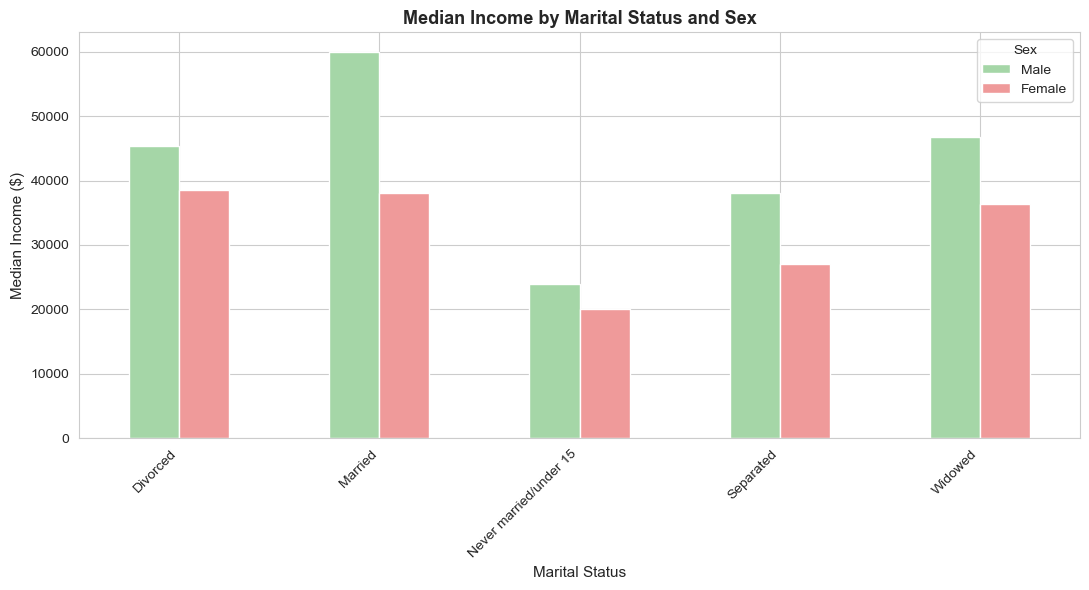

In [106]:
# Decode marital status
mar_mapping = {
    1: 'Married',
    2: 'Widowed', 
    3: 'Divorced',
    4: 'Separated',
    5: 'Never married/under 15'
}

income_df['marital_status'] = income_df['MAR'].map(mar_mapping)

# Calculate median income
income_by_mar_sex = income_df.groupby(['marital_status', 'sex'])['PINCP'].median().unstack()

# Calculate gap
income_by_mar_sex['Gap ($)'] = income_by_mar_sex['Male'] - income_by_mar_sex['Female']
income_by_mar_sex['Women earn (%)'] = (income_by_mar_sex['Female'] / income_by_mar_sex['Male']) * 100

print("Median Income by Marital Status and Sex:")
print(income_by_mar_sex.round(0))

# Visualize
fig, ax = plt.subplots(figsize=(11, 6))
income_by_mar_sex[['Male', 'Female']].plot(kind='bar', ax=ax, color=['#A5D6A7','#EF9A9A'])
plt.ylabel('Median Income ($)', fontsize=11)
plt.xlabel('Marital Status', fontsize=11)
plt.title('Median Income by Marital Status and Sex', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex', fontsize=10)
plt.tight_layout()
plt.show()

**Finding:** The gender pay gap varies dramatically by marital status:

| Marital Status | Male Income | Female Income | Gap | Women Earn |
|---------------|-------------|---------------|-----|------------|
| **Married** | ~$60,000 | ~$38,000 | ~$22,000 | **63%** |
| **Divorced** | ~$45,000 | ~$39,000 | ~$7,000 | **85%** |
| **Never married** | ~$38,000 | ~$32,000 | ~$6,000 | **84%** |

**Key observations:**
1. **Marriage is associated with the largest gender pay gap** - married women earn only 63% of what married men earn
2. **The gap narrows significantly for divorced women** - they earn 85% of what divorced men earn
3. **Never married individuals have a smaller gap** than married couples
4. **Men receive a "marriage premium"** - married men earn more than unmarried men
5. **Women face a "marriage penalty"** - married women earn less than divorced women

**What this suggests:**
- Marriage or household partnership is strongly correlated with income disparities
- Traditional household divisions of labor may emerge within marriages
- Women may reduce hours, change careers, or exit workforce after marriage
- Caregiving responsibilities may fall disproportionately on married women

**What this STILL doesn't tell us:**
- **Causation vs correlation:** Does marriage cause lower earnings, or do lower-earning women marry?
- **Presence of children:** Are married women more likely to have children requiring care?
- **Who does unpaid labor:** How is domestic work divided within marriages?
- **Career sacrifices:** Did women relocate or change jobs for partner's career?
- **Career interruptions:** Did women take time off for childbearing/childrearing?
- **Part-time status:** Are married women more likely to work part-time?
- **Timing:** Does the gap predate marriage or emerge after marriage?
- **Decision-making:** Are these "choices" or constraints shaped by lack of childcare, workplace inflexibility, or social expectations?

**The pattern is crystal clear - marriage correlates with larger pay gaps. The mechanism driving this pattern remains invisible.** Without understanding causation, we cannot determine whether policy should focus on childcare subsidies, workplace flexibility, cultural norms, or discrimination enforcement.



---

### 4.6 What We CANNOT See: The Missing Mechanisms

The analyses in sections 4.3 through 4.5 follow a consistent pattern: **we can document associations, but we cannot identify mechanisms.**

We've established:
- ✅ Household role matters (but doesn't explain the gap)
- ✅ Hours worked are equal (but gaps persist)
- ✅ Occupational segregation exists (but gaps exist within occupations too)
- ✅ Marital status correlates with larger gaps (but we don't know why)

**Each finding reveals a pattern. None reveals a mechanism.**

The fundamental limitation is that **critical variables are absent** from the dataset. Without these variables, we cannot distinguish between vastly different causal pathways—and different pathways require completely different policy responses.

**Missing variables by category:**

#### Work Intensity & Flexibility
- Full-time vs part-time employment classification
- Availability for overtime, irregular schedules, or travel
- Flexibility constraints (need for predictable 9-5 vs ability to work variable hours)
- Remote work availability and usage
- Shift work patterns (night shifts, weekends)

#### Caregiving Burden
- Presence and ages of children (especially children under 6)
- Number of children in household
- Single parent status
- Eldercare responsibilities
- Disabled family member care
- Access to and cost of childcare
- Childcare arrangements (family vs paid vs none)

#### Career Patterns & Continuity
- Total years of work experience in current field
- Career interruptions (gaps in employment) and their duration
- Reason for employment gaps (childbearing, eldercare, education, layoff)
- Time since return to workforce after career break
- Job changes due to family relocation or partner's career
- Frequency of job changes and reasons
- Promotion history and timing

#### Within-Occupation Detail
- Entry-level vs mid-level vs senior positions
- Management vs individual contributor status
- Supervisory responsibilities (number of direct reports)
- Budget authority and decision-making power
- Years of experience at current position/level
- Path to current role (promoted internally vs hired externally)
- Industry within occupation (e.g., retail manager vs tech manager)

#### Unpaid Labor & Time Allocation
- Hours per week spent on domestic work
- Responsibility for household management and coordination
- Mental load (planning, scheduling, organizing family life)
- Division of household labor with partners
- Time spent on childcare vs paid childcare usage
- Time constraints affecting work availability

#### Workplace Dynamics & Negotiation
- Starting salary vs current salary
- Salary negotiation attempts and outcomes
- Requests for raises or promotions and responses
- Access to mentorship and sponsorship
- Professional networks and social capital
- Workplace discrimination experiences
- Flexibility to advocate for advancement

**Without these variables, we face a fundamental analytical barrier:** We cannot distinguish between scenarios that look identical in the current data but require completely different interventions.

#### Examples of indistinguishable scenarios:

| **Observed pattern** | **Possible mechanism 1** | **Possible mechanism 2** | **Possible mechanism 3** |
|---------------------|------------------------|------------------------|------------------------|
| Women earn less | Women choose part-time for work-life balance | Women cannot find full-time work compatible with childcare | Direct pay discrimination for same work |
| Married women earn least | Women voluntarily reduce hours after marriage | Household labor falls disproportionately on women | Employers discriminate against married women |
| Gap persists across education | Women choose lower-paying fields | Women steered away from high-paying fields by advisors/culture | Women face promotion barriers within same fields |
| Female managers earn less | Women manage smaller teams/budgets | Women denied promotions to higher management levels | Women negotiate less or penalized for negotiating |

**Each mechanism demands a different policy response:**
- Mechanism 1 (choice) → Cultural change, role model visibility
- Mechanism 2 (constraint) → Childcare subsidies, workplace flexibility mandates
- Mechanism 3 (discrimination) → Pay transparency laws, enforcement, penalties

**The data shows us the outcome. It hides the mechanism. Policy requires mechanisms.**



---

### 4.7 Why This Matters: The Policy Problem

The absence of mechanism data creates a fundamental challenge for evidence-based policymaking. **Policy interventions operate on mechanisms, not outcomes.**

Simply knowing "women earn less" or "married women earn least" cannot guide effective policy because the same outcome could stem from dozens of different causes—each requiring different interventions.

**Without mechanism data, policymakers cannot answer critical questions:**

| **Policy Question** | **Requires Understanding...** | **Current ACS Data Provides...** |
|-------------------|----------------------------|--------------------------------|
| Should we subsidize childcare? | Whether caregiving burden drives income gaps | ❌ No data on children or caregiving |
| Should we mandate pay transparency? | Whether discrimination occurs within same roles | ❌ Can't control for experience, position level, hours |
| Should we expand parental leave? | Whether career interruptions explain gaps | ❌ No data on employment continuity or breaks |
| Should we enforce equal pay laws more strictly? | Whether unexplained gaps remain after controlling for everything | ❌ Can't isolate discrimination from other factors |
| Should we support flexible work arrangements? | Whether rigid schedules disadvantage caregivers | ❌ No data on schedule constraints or flexibility needs |
| Should we address occupational segregation? | Whether women are pushed out of high-paying fields or choosing them | ❌ Can't determine causation or barriers |
| Should we invest in negotiation training for women? | Whether negotiation gaps drive pay differences | ❌ No data on negotiation attempts or outcomes |
| Should we target promotion barriers? | Whether women face discrimination in advancement | ❌ Can't see within-occupation position or promotion history |

**The result:** Policymakers must choose interventions based on assumptions, ideology, or incomplete evidence rather than clear data about mechanisms.

**Real-world consequences:**

- **Inefficient resource allocation:** Investing in interventions that don't address actual mechanisms
- **Missed opportunities:** Failing to identify and address the most impactful leverage points
- **Inability to measure success:** Can't determine if policies work because we can't identify what they're supposed to change
- **Political deadlock:** Debates about solutions occur without shared understanding of problems
- **Continued inequality:** Visible disparities persist because mechanisms remain unaddressed

**Example scenario:**

A state legislature debates childcare subsidies to address the gender pay gap.

**With current data:**
- Supporters argue: "Women earn less, especially married women—this must be due to childcare burden"
- Opponents argue: "Women choose lower-paying fields and part-time work—subsidies won't help"
- Both cite the same ACS data showing women earn 63% of what married men earn
- Neither can prove their mechanism
- Policy decision rests on ideology, not evidence

**With mechanism data:**
- Analysis could show: "73% of the marriage pay gap is explained by hours reduction correlated with having children under 5"
- Or: "Only 23% of the gap relates to hours; 45% remains after controlling for hours, occupation, and experience"
- Policy debate becomes evidence-based: "Do we address childcare constraints or discrimination?"

**The fundamental issue:** We've invested in measuring **who is disadvantaged** (women, married women, women of color) but not **why and how they're disadvantaged** (mechanisms). 

Inequality remains legible—we can see it, document it, track it over time—but unaddressable, because we lack the data infrastructure to identify where and how to intervene effectively.

**This isn't a failure of analysis. It's a structural limitation of the data we collect.**

---

## 5. The Data Infrastructure Problem

This analysis reveals a fundamental structural limitation in how we collect data about inequality.

### 5.1 The Current Paradigm: Outcomes Over Mechanisms

**What we prioritize collecting:**
- Demographics (age, sex, race, education)
- Outcomes (income, employment status, occupation)
- Descriptive categories (household structure, marital status)

**What we systematically under-collect:**
- Work patterns (hours distribution, flexibility, continuity)
- Caregiving responsibilities (children, elderly, household labor)
- Career dynamics (interruptions, promotions, negotiations)
- Within-category detail (job level, experience, advancement)

**The result:** Data systems optimized for **visibility** but not **actionability**.

### 5.2 When "Good" Data Isn't Good Enough

The ACS dataset exemplifies responsible data collection in many ways:
- ✅ Gender-disaggregated (includes sex as a variable)
- ✅ Balanced representation (~50/50 male/female)
- ✅ Comprehensive documentation (clear codebooks, accessible)
- ✅ Large sample size (statistically robust)
- ✅ Geographic coverage (all 50 states)
- ✅ Regular updates (annual data collection)

**Yet it still cannot answer the most critical policy question: Why does inequality persist, and what mechanisms drive it?**

This isn't a criticism of the ACS—it's fulfilling its design purpose (demographic and economic profiles). The problem is that **we've built a data ecosystem where well-designed outcome measurement is the norm, and mechanism measurement is the exception.**

### 5.3 The Visibility-Actionability Gap

As Criado Perez argues in *Invisible Women*, simply collecting gender-disaggregated data is necessary but not sufficient for addressing inequality.

**Three levels of data sophistication:**

**Level 1: Invisibility**
- Gender not tracked at all
- Inequality literally invisible in data
- *Example:* Early crash test data using only male dummies

**Level 2: Visibility** ← *The ACS is here*
- Gender tracked and disaggregated
- Inequality documented and measurable
- Patterns clearly visible
- *Example:* ACS shows women earn 71% of men

**Level 3: Actionability** ← *Where we need to be*
- Mechanisms identified and measurable
- Causal pathways distinguishable
- Interventions testable
- *Example:* Data showing "X% of gap due to caregiving, Y% due to discrimination, Z% unexplained"

**We've successfully moved from Level 1 to Level 2. We're stuck at Level 2 because we haven't invested in the data infrastructure for Level 3.**

### 5.4 The Core Insight

> **"Good data makes problems visible. Better data makes problems actionable."**

The ACS has achieved visibility:
- The gender pay gap is undeniable
- It persists across education, occupation, age, and geography
- It compounds intersectionally
- It correlates with marriage and household structure
- We can track it over time

**But visibility without mechanisms creates a policy stalemate:**
- We know inequality exists
- We can measure its magnitude
- We cannot determine why it persists
- We cannot design targeted interventions
- We cannot measure whether interventions work

**If governments only invest in datasets that document outcomes (who is disadvantaged) but not mechanisms (why and how), then inequality remains legible but unaddressable.**

### 5.5 A Structural, Not Individual, Problem

This isn't about:
- ❌ The ACS being "badly designed"
- ❌ Researchers not being creative enough
- ❌ Lack of statistical sophistication

It's about:
- ✅ **Systematic underinvestment** in mechanism measurement across data infrastructure
- ✅ **Institutional priorities** that favor descriptive over explanatory data
- ✅ **Data collection norms** that stop at documenting disparities
- ✅ **Funding structures** that reward outcome measurement over mechanism identification

**The pattern repeats across domains:**
- Health disparities: We track who gets sick, not why they lack access to care
- Educational gaps: We measure test scores, not barriers to learning
- Housing inequality: We document segregation, not mechanisms maintaining it
- Criminal justice: We count arrests and sentences, not pathways into the system

**In each case: perfect visibility, limited actionability.**

### 5.6 Why Mechanism Data Is Systematically Under-Collected

Several structural factors explain why we prioritize outcome over mechanism data:

**1. Complexity and cost**
- Mechanism variables require more detailed surveys
- Longer questionnaires reduce response rates
- Processing and analysis more resource-intensive

**2. Privacy concerns**
- Mechanism questions feel more invasive
- Asking about childcare, household labor, discrimination experiences raises sensitivity
- Balancing data utility with respondent privacy

**3. Institutional inertia**
- Existing data systems optimized for continuity (tracking trends over time)
- Changing variables makes year-over-year comparison difficult
- Incentives favor maintaining existing measures

**4. Disciplinary silos**
- Economists collect income/employment data
- Sociologists collect time-use and family data
- Policy researchers need both but they're rarely linked
- Data integration across sources is difficult

**5. Outcome bias in accountability**
- Governments measured on whether gaps close, not whether they understand them
- Easier to report "gap narrowed 2%" than "we identified three key mechanisms"
- Political incentives favor simple metrics over complex explanations

**These are real barriers—but they result in a data infrastructure that systematically prioritizes describing problems over solving them.**



---

## 6. Towards Actionable Data Infrastructure -- NEEDS TO BE REVIEWED

### 6.1 What This Analysis Demonstrates

This project has shown:

1. **Representation ≠ fairness ≠ actionability**
   - The ACS includes women (representation ✓)
   - The data shows women earn less (visibility ✓)
   - We cannot design effective policy (actionability ✗)

2. **Well-managed data can still be structurally insufficient**
   - Good documentation doesn't solve mechanism gaps
   - Balanced sampling doesn't reveal causal pathways
   - Comprehensive coverage doesn't enable intervention design

3. **Each layer of analysis reveals new patterns but not mechanisms**
   - Household roles matter → but why?
   - Marriage correlates with gaps → but how?
   - Occupations differ → but why, and what drives it?
   - Same occupation, different pay → but what explains it?

4. **Policy requires what we don't measure**
   - Every intervention requires mechanism knowledge
   - Current data cannot distinguish between causal stories
   - Evidence-based policy is impossible without mechanism data

### 6.2 What Would Actionable Data Infrastructure Look Like?

Moving from visibility to actionability requires **systematic investment in mechanism measurement**:

#### Short-term: Enhance existing surveys

**Expand ACS or create complementary modules to capture:**
- Work intensity: Full/part-time status, actual hours distribution, overtime availability
- Caregiving: Children (ages, number), eldercare, household labor hours
- Career patterns: Years in field, employment gaps and reasons, promotion history
- Workplace flexibility: Schedule control, remote work options, flexibility constraints

#### Medium-term: Link existing datasets

**Create integrated data systems connecting:**
- Income/employment data (ACS) + Time-use data (ATUS)
- Labor market data + Childcare availability and cost data
- Employment records + Educational attainment and field
- Workplace characteristics + Individual outcomes

**Technical challenges exist but are surmountable:**
- Privacy-preserving linkage methods
- Statistical disclosure controls
- Standardized identifiers across datasets

#### Long-term: Build mechanism measurement norms

**Institutionalize mechanism data collection:**
- Funding agencies prioritize mechanism measurement
- Data collection norms shift toward explanatory variables
- Privacy frameworks balance protection with data utility
- Interdisciplinary data standards enable integration
- Longitudinal tracking becomes standard (following individuals over time)

### 6.3 What Better Data Would Enable

With mechanism data, policy analysis could answer questions currently impossible:

**Current question:** "Should we subsidize childcare to reduce the gender pay gap?"

**Current answer:** "Maybe? Women with children probably earn less, but we can't prove it's due to childcare vs other factors, and we can't measure if subsidies would help."

**With mechanism data:** "73% of the marriage pay gap for women with children under 5 is explained by hours reduction. Women in areas with affordable childcare availability work 8 more hours per week on average and earn proportionally more. Childcare subsidies would likely reduce X% of the observed gap."

**The difference:** Evidence-based policy design, measurable interventions, accountability for results.

### 6.4 Limitations and Caveats

**This analysis itself has limitations:**
- Focused on income inequality; other forms of inequality may have different data needs
- U.S.-specific; other countries may have different data infrastructure
- ACS is one dataset; other surveys may capture different variables
- Mechanism measurement is not a complete solution to inequality—it's a prerequisite for effective intervention

**Important acknowledgments:**
- Data collection alone doesn't create equity
- Even perfect data requires political will to act
- Some mechanisms may be impossible to measure
- Privacy and respondent burden are real constraints
- Data is a tool for justice, not justice itself

### 6.5 The Path Forward: From Visibility to Action

**The central argument of this analysis:**

Gender-disaggregated income data successfully makes inequality visible. The ACS dataset is well-designed, comprehensive, and documented. It proves the gender pay gap exists, is persistent, and compounds intersectionally.

**But visibility is only the first step.**

Without mechanism data, inequality remains a documented problem without a clear path to solution. Policymakers can see the gap but cannot determine why it exists or how to address it effectively. Interventions are designed on assumptions rather than evidence. Success cannot be measured because causal pathways are unknown.

**This is a data infrastructure problem.** Not a failure of the ACS or any individual dataset, but a systematic underinvestment in the kind of data needed for actionable policymaking.

**Moving forward requires:**

1. **Recognizing the limitation:** Outcome data alone is insufficient for equity
2. **Investing in mechanisms:** Funding data collection that captures why and how
3. **Building integration:** Linking datasets across domains and over time
4. **Shifting norms:** Making mechanism measurement standard practice
5. **Demanding actionability:** Holding institutions accountable for collecting data that enables solutions, not just documentation

**The insight:**
> "Good data makes problems visible. Better data makes problems actionable."

**We've achieved visibility. Now we must build toward actionability.**

---



## 7. Conclusion - NEEDS REVIEW

This analysis began with a simple observation: despite being well-documented, gender-disaggregated, and comprehensive, the ACS income data reveals persistent inequality but cannot explain its mechanisms.

**What we found:**
- Women earn 29% less than men at the median
- This gap persists across education levels, occupations, age groups, and household roles
- Even female managers earn 29% less than male managers in the same occupation code
- Married women face the largest penalty (earning only 63% of married men's income)
- Both sexes work 40 hours median, yet gaps remain
- Occupational segregation exists but doesn't fully explain disparities

**What we learned:**
Every layer of analysis revealed patterns, but not mechanisms. We can see associations but cannot identify causation. We can document outcomes but cannot design targeted interventions.

**The core insight:**
Representation in data (including gender) ≠ fairness in outcomes ≠ actionability for policy.

The ACS exemplifies Level 2 data sophistication (visibility) but cannot reach Level 3 (actionability) because critical mechanism variables are absent. This isn't a failure of the ACS—it's a structural gap in our data infrastructure.

**The implication:**
If governments only invest in measuring who is disadvantaged but not why and how, then inequality remains legible but unaddressable. Policy operates with perfect visibility but limited understanding.

**The path forward:**
Moving from visibility to actionability requires systematic investment in mechanism measurement: work patterns, caregiving responsibilities, career dynamics, within-occupation detail, and time allocation data. This means enhancing surveys, linking datasets, and building new norms around what responsible data collection requires.

**As Criado Perez argues in *Invisible Women*:** Gender-disaggregated data is necessary but not sufficient. We've learned to count women. Now we must learn to understand the mechanisms that disadvantage them—and build the data infrastructure to make that understanding actionable.

**Until we measure not just who is disadvantaged but why and how, inequality will remain a documented problem without a clear path to solution.**

The data makes the problem visible. Better data could make it solvable.